# Data Transformations

> Functions for getting, splitting, and labeling data

In [ ]:
#| default_exp data.tfms

In [ ]:
#| hide
from nbdev.showdoc import *
from fastcore.test import *

In [ ]:
#| export

# =================================
# Standard library
# =================================
import os
import random
from inspect import signature, _empty

# =================================
# Third-party scientific stack
# =================================
import h5py
import numpy as np
import pandas as pd
from tqdm import tqdm

# =================================
# Bioimage IO
# =================================
from bioio import BioImage as AICSImage
from bioio import Writer as OmeTiffWriter

# =================================
# PyTorch
# =================================
from torch.utils.data import DataLoader as torchDataLoader

# =================================
# fastai
# =================================
from fastai.vision.all import get_grid

# =================================
# MONAI
# =================================
from monai.inferers import SlidingWindowSplitter, Splitter

# =================================
# bioMONAI
# =================================
from bioMONAI.utils import *
from bioMONAI.io import image_reader, _sanitize
from bioMONAI.data.core import *
from bioMONAI.data.load import *

# =================================
# fasttransform patch
# =================================
import fasttransform

_original_repr = fasttransform.transform.Transform.__repr__

def _safe_repr(self):
    try:
        return _original_repr(self)
    except AttributeError as e:
        if "'_BoundFunction' object has no attribute 'methods'" in str(e):
            return f"{self.__class__.__name__}(...)"
        raise

fasttransform.transform.Transform.__repr__ = _safe_repr

## Data getters

Functions to retrieve specific data components are provided, aiding in the organization and preprocessing of datasets.

In [ ]:
#| export
from fastai.vision.all import get_image_files
from typing import Callable
import re
from glob import glob as glob_expand

In [ ]:
#| export
def _glob_to_regex(pattern: str) -> str:
    pattern = re.escape(pattern)
    pattern = pattern.replace(r"\*", ".*")
    pattern = pattern.replace(r"\?", ".")
    pattern = pattern.replace(r"\[", "[")
    pattern = pattern.replace(r"\]", "]")
    return f"^{pattern}$"


def _build_filename_predicate(
    filename_filter: str|re.Pattern|Callable[[str], bool]
) -> Callable[[str], bool]:
    """
    Build a filename predicate function from the provided filter.
    """

    if isinstance(filename_filter, str):
        if any(c in filename_filter for c in "*?["):
            regex = re.compile(_glob_to_regex(filename_filter))
            return lambda name: regex.search(name) is not None
        return lambda name: filename_filter in name

    if isinstance(filename_filter, re.Pattern):
        return lambda name: filename_filter.search(name) is not None

    if callable(filename_filter):
        return filename_filter

    raise ValueError("Unsupported filename_filter type")


def get_images(
    path: str|Path,
    folders: str|list[str]|None = None,
    recurse: bool = True,
    filename_filter: str|re.Pattern|Callable[[str], bool]|None = None,
) -> L:
    """
    Get image files from a list of folders or a glob expression.
    """

    # Resolve folders
    if folders is None:
        files = get_image_files(path, recurse=recurse)
    else:
        if isinstance(folders, str):
            if any(c in folders for c in "*?["):
                expanded = sorted(glob_expand(os.path.join(path, folders)))
                img_folders = (
                    [os.path.basename(p) for p in expanded]
                    if expanded else [folders]
                )
            else:
                img_folders = [folders]
        else:
            img_folders = list(folders)

        files = get_image_files(path, folders=img_folders, recurse=recurse)

    # No filtering requested
    if filename_filter is None:
        return files

    # Build filtering function
    predicate = _build_filename_predicate(filename_filter)

    # Apply filtering
    filtered = L()
    for f in files:
        name = os.path.basename(f)
        if predicate(name):
            filtered.append(f)

    return filtered

In [ ]:
#| export
def get_gt(path_gt, # The base directory where the ground truth files are stored, or a file path from which to derive the parent directory.
           gt_file_name="avg50.png", # The name of the ground truth file.
           ):
    """
    The `get_gt` function retrieves ground truth data, essential for supervised learning tasks. 
    It ensures that the correct labels or annotations are associated with each data sample.
    
    This function constructs a path to a ground truth file based on the given `path_gt` and `gt_file_name`.    
    It uses a lambda function to create a new path by appending `gt_file_name` to 
    the parent directory of the input file, as specified by `path_gt`.
    
    Returns a callable: A function that takes a single argument (a filename) and returns a Path object 
                   representing the full path to the ground truth file. When called with a filename, 
                   this function constructs the path by combining `path_gt` or the parent directory of 
                   the filename with `gt_file_name`. 
    """
    
    # Convert path_gt to Path object if it's a string
    path_gt = Path(path_gt)
    
    # Define the lambda function that constructs the full path
    _fn = lambda fn: path_gt / f"{Path(fn).parent}" / gt_file_name
    
    return _fn


The `get_target` function constructs and returns functions for generating file paths to "target" files based on given input parameters. 
This function is particularly useful for tasks where the target files are stored in a different directory or have a different naming convention compared to the input files.


In [ ]:
#| export
def get_target(path:str, # The base directory where the files are located. This should be a string representing an absolute or relative path.
               same_filename=True, #If True, the target file name will match the original file name; otherwise, it will use the specified prefix. 
               same_foldername=False, #If True, the target folder name will match the original folder name; otherwise, it will use the specified prefix.
               target_file_prefix="target", # The prefix to insert into the target file name if `same_filename` is False. 
               signal_file_prefix="signal", # The prefix used in the original file names that should be replaced by the target prefix.
               map_foldername=False, #If True, the target folder name will match the original folder name; otherwise, it will use the specified prefix. 
               target_folder_prefix="target", # The prefix to insert into the target folder name if `same_foldername` is False. 
               signal_folder_prefix="signal", # The prefix used in the original folder names that should be replaced by the target prefix. 
               relative_path=False, # If True, it indicates that the path is relative to the parent folder in the path where the input files are located.
               ):
    """
    Constructs and returns functions for generating file paths to "target" files based on given input parameters.
    
    This function defines two nested helper functions within its scope: \n
        - `construct_target_filename(file_name)`: Constructs a target file name by inserting the specified prefix into the original file name.
        - `generate_target_path(file_name)`: Generates a path to the target file based on whether `same_filename` is set to True or False.
    
    The main function returns the appropriate helper function based on the value of `same_filename`.
    
    Returns a callable: A function that takes a file name as input and returns its corresponding target file path based on the specified parameters.
    
    """
    # Define a function to construct the target file name based on input parameters
    def construct_target_filename(file_name):
        # Split the file name based on the signal file prefix
        parts = file_name.split(signal_file_prefix)   
        # Construct the target file name by inserting the target file prefix
        target_file_name = parts[0] + target_file_prefix + parts[1]
        
        return target_file_name
    
    def construct_target_foldername(folder_name):
        # Split the folder name based on the signal folder prefix
        parts = folder_name.split(signal_folder_prefix)
        # Construct the target folder name by inserting the target folder prefix
        target_folder_name = parts[0] + target_folder_prefix + parts[1]
        
        return target_folder_name
    
    # Define a function to generate the target file path based on the given file name
    def generate_target_path(file_name):
        
        if map_foldername:
            # Extract the folder name and replace the signal folder prefix with the target folder prefix
            folder_name = os.path.dirname(file_name)
            target_folder_name = Path(construct_target_foldername(folder_name))
        elif same_foldername:
            target_folder_name = Path(os.path.dirname(file_name))
        else:
            base_path = ''
            if relative_path:
                base_path = Path(file_name).parents[1]
            target_folder_name = base_path / Path(path)
                            
        # Extract the base file name
        base_filename = os.path.basename(file_name)
        
        # If same_filename is True, simply return the path joined with the base file name
        if same_filename:
            return target_folder_name / base_filename
        
        # If same_filename is False, construct the target file name and return the path joined with it
        target_filename = construct_target_filename(base_filename)
        return target_folder_name / target_filename
    
    # Return the appropriate function based on the value of same_filename
    return generate_target_path



The function `get_target` can be used to look for target files in different folders using either absolute or relative paths:

In [ ]:
print(get_target('train_folder/target', same_filename=False)('../signal/signal01.tif'))
print(get_target('target', relative_path=True)('../train_folder/signal/image01.tif'))

train_folder/target/target01.tif
../train_folder/target/image01.tif


...and it can look for target files with different names but same numbering:

In [ ]:
print(get_target('GT', relative_path=True, same_filename=False, target_file_prefix="image_clean", signal_file_prefix="image_noisy")('train_folder/signal/image_noisy_01.tif'))

train_folder/GT/image_clean_01.tif


It also supports more general cases:

In [ ]:
print(get_target('GT', relative_path=True, same_filename=False, target_file_prefix="clean", signal_file_prefix="noisy")('train_folder/signal/01_image_noisy_dataset.tif'))

train_folder/GT/01_image_clean_dataset.tif


In [ ]:
print(get_target('', relative_path=True, map_foldername=True, target_folder_prefix="GT", signal_folder_prefix="signal")('train_folder/signal_01/01_1.tif'))

train_folder/GT_01/01_1.tif


For tasks involving unsupervised denoising or noise analysis, `get_noisy_pair` retrieves pairs of noisy data, enabling the training of models such as N2N.


In [ ]:
#| export
def get_noisy_pair(fn):
    """
    Get another "noisy" version of the input file by selecting a file from the same directory.
    
    This function first retrieves all image files in the directory of the input file `fn` (excluding subdirectories). 
    It then selects one of these files at random, ensuring that it is not the original file itself to avoid creating a trivial "noisy" pair.
    
    Parameters: \n
        fn (Path or str): The path to the original image file. This should be a Path object but accepts string inputs for convenience.
    
    Returns: \n
        Path: A Path object pointing to the selected noisy file.
    
    """
    
    # Convert fn to Path object if it's not already one
    fn = Path(fn)
    
    # Get all image files in the parent directory of the input file
    tmp = get_image_files(fn.parent, recurse=False)
    
    # Select a random file from the list, ensuring it's not the original file
    fn2 = tmp[randint(0, len(tmp) - 1)]
    while fn2 == fn:
        fn2 = tmp[randint(0, len(tmp) - 1)]
    
    return fn2


## Data Display

Visualization functions are included to display batches of data and model results, aiding in qualitative assessments and debugging.


In [ ]:
#| export
@typedispatch
def show_batch(x: BioImageBase,     # The input image data.
               y: BioImageBase,     # The target image data.
               samples,             # List of sample indices to display.
               ctxs=None,           # List of contexts for displaying images. If None, create new ones using get_grid().
               max_n: int=9,       # Maximum number of samples to display. Default is 9.
               nrows: int|None=None,     # Number of rows in the grid if ctxs are not provided.
               ncols: int|None=None,     # Number of columns in the grid if ctxs are not provided.
               figsize: tuple|None=None, # Figure size for the image display.
               **kwargs,            # Additional keyword arguments to pass to the show method of BioImageBase.
               ):
    """
    Display a batch of images and their corresponding targets.
    
    Returns:
        List[Context]: A list of contexts after displaying the images and targets.
    """
    # If ctxs are not provided, create new ones using get_grid()
    if ctxs is None:
        ctxs = get_grid(min(len(samples), max_n), nrows=nrows, ncols=ncols, figsize=figsize, double=True)
    
    # Loop through the images and targets in pairs (x and y)
    for i in range(2):
        # Display each image-target pair in a specific context
        ctxs[i::2] = [b.show(ctx=c, **kwargs) for b, c, _ in zip(samples.itemgot(i), ctxs[i::2], range(max_n))]
    
    return ctxs


In [ ]:
#| export
from fastai.vision.all import TensorCategory

In [ ]:
#| export
@typedispatch
def show_batch(x: BioImageBase,      # The input image data.
               y: TensorCategory,    # The target data (categorical labels).
               samples,              # List of sample indices to display.
               ctxs=None,            # List of contexts for displaying images. If None, create new ones using get_grid().
               max_n: int=9,        # Maximum number of samples to display. Default is 9.
               nrows: int|None=None,      # Number of rows in the grid if ctxs are not provided.
               ncols: int|None=None,      # Number of columns in the grid if ctxs are not provided.
               figsize: tuple|None=None,  # Figure size for the image display.
               **kwargs,             # Additional keyword arguments to pass to the show method of BioImageBase.
               ):
    """
    Display a batch of images with their corresponding labels as titles.
    
    Returns:
        List[Context]: A list of contexts after displaying the images and their labels.
    """
    # If ctxs are not provided, create new ones using get_grid()
    if ctxs is None: 
        ctxs = get_grid(min(len(samples), max_n), nrows=nrows, ncols=ncols, figsize=figsize)
    
    # Flatten the context in case it returns as an array
    if isinstance(ctxs, np.ndarray):
        ctxs = ctxs.flatten()
    
    # Extract the input images and the corresponding labels
    xs, ys = samples.itemgot(0), samples.itemgot(1)

    # Loop through the images and labels
    for i in range(len(xs)):
        # Display each input image
        ctxs[i] = xs[i].show(ctx=ctxs[i], title=f"Label: {ys[i]}", **kwargs)
    
    return ctxs

In [ ]:
#| export
@typedispatch
def show_batch(
    x: list[MetaTensor|torchTensor],   # inputs
    y: MetaTensor|torchTensor|list,    # targets
    samples: list|None=None,           # List of sample indices to display.
    ctxs=None,                         # List of contexts for displaying images. If None, create new ones using get_grid().
    max_n: int=9,                      # Maximum number of samples to display. Default is 9.
    nrows: int|None=None,      # Number of rows in the grid if ctxs are not provided.
    ncols: int|None=None,      # Number of columns in the grid if ctxs are not provided.
    figsize: tuple|None=None,  # Figure size for the image display.
    vocab=None,
    **kwargs
):
    """
    Show `max_n` inputs and targets from a batch.

    Supports both MetaTensor and torch.Tensor inputs.
    Converts to BioImage/BioImageMulti automatically.
    """

    # -------------------------
    # Create samples if not provided
    # -------------------------
    if samples is None:

        # Ensure x is a list
        if isinstance(x, (MetaTensor, torchTensor)):
            if x.ndim == 4:        # batch tensor
                x = [x[i] for i in range(len(x))]
            else:
                x = [x]

        elif isinstance(x, list) and isinstance(x[0], (MetaTensor, torchTensor)) and x[0].ndim > 3:
            # flatten batch dimension
            x = [t[i] for t in x for i in range(t.shape[0])]

        # -------------------------
        # Convert tensors → BioImage
        # -------------------------
        cls = BioImage if x[0].shape[0] == 1 else BioMultiChannel
        x_bio = [Tensor2BioImage(cls)(t) for t in x]

        # -------------------------
        # Convert y to list
        # -------------------------
        if isinstance(y, (MetaTensor, torchTensor)):
            if y.ndim == 0:
                y_list = [int(y)]
            else:
                y_list = [int(y[i]) for i in range(len(y))]
        else:
            y_list = list(y)

        if vocab is not None:
            y_list = [vocab[o] for o in y_list]

        samples = L(zip(x_bio, y_list))

    # -------------------------
    # Create grid if ctxs not provided
    # -------------------------
    if ctxs is None:
        ctxs = get_grid(min(len(samples), max_n), nrows=nrows, ncols=ncols, figsize=figsize)

    # -------------------------
    # Display
    # -------------------------
    for i, ((img, lbl), ax) in enumerate(zip(samples, ctxs)):
        if i >= max_n: break
        img.show(ctx=ax, **kwargs)
        ax.set_title(str(lbl), fontsize=10)

    return ctxs

### show_batch
> ```  
> show_batch (x:BioImageBase, y:BioImageBase, samples,
>             ctxs=None, max_n:int=10, nrows:int=None, ncols:int=None,
>             figsize:tuple=None, **kwargs)
> ```


The `show_batch` function visualizes a batch of data samples, allowing users to inspect the input data and verify preprocessing steps.

Returns: List[Context]: A list of contexts after displaying the images and labels.

| | Type           | Default     | Details                                                         |
|-----------|-----|-------------|-----------------------------------------------------------------|
| x              | BioImageBase | | The input image data.                                           |
| y              | BioImageBase | | The target label data.                                          |
| samples        |             | | List of sample indices to display.                              |
| ctxs           | NoneType     | | List of contexts for displaying images. If None, create new ones using `get_grid()`. |
| max_n          | int          | 10 | Maximum number of samples to display.        |
| nrows          | int          | None | Number of rows in the grid if `ctxs` are not provided.      |
| ncols          | int          | None | Number of columns in the grid if `ctxs` are not provided.   |
| figsize        | tuple        | None | Figure size for the image display.                          |
| kwargs         |            | | Additional keyword arguments.                                   |



In [ ]:
#| export 
@typedispatch
def show_results(x: BioImageBase, # The input image data.
                 y: BioImageBase, # The target label data.
                 samples, # List of sample indices to display.
                 outs, # List of output predictions corresponding to the samples.
                 ctxs=None, # List of contexts for displaying images. If None, create new ones using get_grid().
                 max_n: int=10, # Maximum number of samples to display.
                 figsize: tuple|None=None, # Figure size for the image display.
                 **kwargs, # Additional keyword arguments to pass to the show method of BioImageBase.
                 ):
    """
    Display a batch of input images along with their predicted and target labels.
   
    Returns: \n
        List[Context]: A list of contexts after displaying the images and labels.
    """
    # If ctxs are not provided, create new ones using get_grid() with a specific title and size
    if ctxs is None: 
        ctxs = get_grid(3 * min(len(samples), max_n), ncols=3, figsize=figsize, title='Input/Target/Prediction')
    
    # Loop through the images and display them in a specific context for input (x) and output predictions (outs)
    for i in range(2):
        ctxs[i::3] = [b.show(ctx=c, **kwargs) for b, c, _ in zip(samples.itemgot(i), ctxs[i::3], range(max_n))]
    
    # Display the target labels (y) in a specific context after the input images
    ctxs[2::3] = [b.show(ctx=c, **kwargs) for b, c, _ in zip(outs.itemgot(0), ctxs[2::3], range(max_n))]
    
    return ctxs


In [ ]:
#| export
@typedispatch
def show_results(x: BioImageBase,       # The input image data.
                y: TensorCategory,      # The target data (categorical labels).
                samples,                # List of sample indices to display.
                outs,                   # List of output predictions corresponding to the samples.
                ctxs=None,              # List of contexts for displaying images. If None, create new ones using get_grid().
                max_n: int=10,               # Maximum number of samples to display.
                nrows: int|None=None,        # Number of rows in the grid if ctxs are not provided.
                ncols: int|None=None,        # Number of columns in the grid if ctxs are not provided.
                figsize: tuple|None=None,           # Figure size for the image display.
                **kwargs,               # Additional keyword arguments to pass to the show method of BioImageBase.
                ):
    """
    Display a batch of input images along with their predicted and target labels.
   
    Returns: \n
        List[Context]: A list of contexts after displaying the images and labels.
    """
    # If ctxs are not provided, create new ones using get_grid() with a specific title and size
    if ctxs is None: 
        ctxs = get_grid(min(len(samples), max_n), nrows=nrows, ncols=ncols, figsize=figsize, title='Target/Prediction')
    
    # Loop through the images and display them in a specific context for input (x) and output predictions (outs)
    for i in range(2):
        ctxs = [b.show(ctx=c, **kwargs) for b,c,_ in zip(samples.itemgot(i),ctxs,range(max_n))]
    
    # Display predictions and target labels (y) in green, when matching, or red, otherwise.
    ctxs = [r.show(ctx=c, color='green' if b==r else 'red', **kwargs)
            for b,r,c,_ in zip(samples.itemgot(1), outs.itemgot(0), ctxs, range(max_n))]
    
    return ctxs


In [ ]:
#| export
@typedispatch
def show_results(dl: torchDataLoader,         # DataLoader containing the batch and optional vocab
                 batch: list,                # The batch of data from the DataLoader (inputs, targets)
                 preds: MetaTensor|torchTensor,          # Model predictions corresponding to the batch
                 ctxs=None,                  # Optional: list of axes to plot on. If None, created automatically
                 max_n: int=10,              # Maximum number of samples to display
                 nrows: int|None=None,       # Number of rows in the grid if ctxs are not provided
                 ncols: int|None=None,       # Number of columns in the grid if ctxs are not provided
                 figsize: tuple|None=None,   # Figure size for the display grid
                 **kwargs                     # Additional keyword arguments passed to `BioImage.show`
                ):
    """
    Display a batch of images with their ground truth labels and predicted labels.

    This version supports `BioImage` or `BioImageMulti` depending on input channels,
    and will use `dl.vocab` to convert integer class indices to class names if available.

    Args:
        dl (torchDataLoader): DataLoader providing the batch and optional `vocab`.
        batch (list): A tuple/list `(x, y)` containing input tensors and labels.
        preds (MetaTensor): Model outputs for the batch.
        ctxs (list, optional): Predefined plotting axes. If None, axes are created automatically.
        max_n (int): Maximum number of samples to display.
        nrows (int | None): Number of rows in the grid if ctxs not provided.
        ncols (int | None): Number of columns in the grid if ctxs not provided.
        figsize (tuple | None): Figure size for the display grid.
        **kwargs: Additional arguments to pass to `BioImage.show`.

    Returns:
        list: List of matplotlib axes containing the displayed images with labels.
    """

    x, y = batch

    # Choose the right BioImage class based on channels
    cls = BioImage if x[0].shape[0]==1 else BioMultiChannel
    x_bio = [Tensor2BioImage(cls)(t) for t in x]

    # Convert predictions and labels to lists
    y_list = y.tolist()
    preds_list = TensorCategory(preds).tolist()

    # Map indices to class names if DataLoader has vocab
    if hasattr(dl, 'vocab') and dl.vocab is not None:
        y_list = [dl.vocab[o] for o in y_list]
        preds_list = [dl.vocab[o] for o in preds_list]

    # Combine images and true labels
    samples = L(zip(x_bio, y_list))

    # Create grid of axes if not provided
    if ctxs is None:
        ctxs = get_grid(min(len(samples), max_n), nrows=nrows, ncols=ncols, 
                        figsize=figsize, title="Target / Prediction")

    # Display images and overlay text for GT vs Pred
    for i, ((img, true_label), pred_label) in enumerate(zip(samples, preds_list)):
        if i >= max_n: break
        ax = ctxs[i]
        img.show(ctx=ax, **kwargs)
        color = 'green' if true_label == pred_label else 'red'
        ax.set_title(f"{true_label} / {pred_label}", color=color, fontsize=10)

    return ctxs

### show_results
> ```
> show_results (x: BioImageBase, y: BioImageBase, samples,
>               outs, ctxs=None, max_n=10, figsize=None, **kwargs)
> ```

After model inference, `show_results` displays the model's predictions alongside the ground truth, facilitating the evaluation of model performance.

Returns:

List[Context]: A list of contexts after displaying the images and labels.


|   | Type           | Default     | Details                                                         |
|-----------|-----|-------------|-----------------------------------------------------------------|
| x              | BioImageBase | | The input image data.                                           |
| y              | BioImageBase | | The target label data.                                          |
| samples        |             | | List of sample indices to display.                              |
| outs           |          |   | List of output predictions corresponding to the samples. |
| ctxs           | NoneType     | | List of contexts for displaying images. If None, create new ones using `get_grid()`. |
| max_n          | int        | 10  | 
| figsize        | tuple        | None | Figure size for the image display.                          |
| kwargs         |            | | Additional keyword arguments.                                   |



## Data Handling

In [ ]:
#| export
def _save_csv(df: pd.DataFrame, path: str) -> None:
    df.to_csv(path, index=False)


def _add_column(
    df: pd.DataFrame,
    column_name: str,
    value,
) -> pd.DataFrame:
    df = df.copy()
    df[column_name] = value
    return df


def _save_separate(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    valid_df: Optional[pd.DataFrame],
    save_dir: str,
    train_path: str,
    test_path: str,
    valid_path: str,
) -> None:

    _save_csv(train_df, os.path.join(save_dir, train_path))
    _save_csv(test_df, os.path.join(save_dir, test_path))

    if valid_df is not None:
        _save_csv(valid_df, os.path.join(save_dir, valid_path))


def _save_single(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    valid_df: Optional[pd.DataFrame],
    save_dir: str,
    combined_path: str,
    split_column: str,
) -> None:

    dfs = [
        _add_column(train_df, split_column, "train"),
        _add_column(test_df, split_column, "test"),
    ]

    if valid_df is not None:
        dfs.append(
            _add_column(valid_df, split_column, "valid")
        )

    combined_df = pd.concat(dfs, ignore_index=True)

    _save_csv(
        combined_df,
        os.path.join(save_dir, combined_path),
    )


def _save_train_valid_together(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    valid_df: Optional[pd.DataFrame],
    save_dir: str,
    test_path: str,
    train_valid_path: str,
    is_valid_column: str,
) -> None:

    # Save test separately
    _save_csv(
        test_df,
        os.path.join(save_dir, test_path),
    )

    dfs = [
        _add_column(
            train_df,
            is_valid_column,
            False,
        )
    ]

    if valid_df is not None:
        dfs.append(
            _add_column(
                valid_df,
                is_valid_column,
                True,
            )
        )

    train_valid_df = pd.concat(dfs, ignore_index=True)

    _save_csv(
        train_valid_df,
        os.path.join(save_dir, train_valid_path),
    )


In [ ]:
#| export
def split_dataframe(
    input_data: Union[str, pd.DataFrame],
    splitter: Callable = RandomSplitter,
    save_mode: str = "separate",
    split_column: str = "split",
    is_valid_column: str = "is_valid",
    train_path: str = "train.csv",
    test_path: str = "test.csv",
    valid_path: str = "valid.csv",
    combined_path: str = "dataset.csv",
    train_valid_path: str = "train_valid.csv",
    data_save_path: Optional[str] = None,
    **kwargs,
) -> tuple:
    """
    Split a dataset into multiple subsets.

    The input dataset can be provided either as a pandas DataFrame
    or as a path to a CSV file. The splitting logic is delegated to
    the provided ``splitter`` callable.

    The splitter may return either:

    - ``(train_df, valid_df)``
    - ``(train_df, valid_df, test_df)``

    The resulting datasets can optionally be saved in different formats:

    - ``"separate"``
        Save each split as an individual CSV file.

    - ``"single"``
        Save all splits into a single CSV file with an additional
        column identifying the split name.

    - ``"train_valid_together"``
        Save the test set separately while combining train and
        validation datasets into one CSV file with an ``is_valid``
        boolean column.

    Args:
        input_data:
            Input dataset as either a pandas DataFrame or a CSV file path.

        splitter:
            Callable responsible for splitting the dataset.

        save_mode:
            Saving strategy for output datasets.
            One of:
            ``"separate"``,
            ``"single"``,
            ``"train_valid_together"``.

        split_column:
            Column name used when ``save_mode="single"``.

        is_valid_column:
            Column name used when
            ``save_mode="train_valid_together"``.

        train_path:
            Filename for the train dataset.

        test_path:
            Filename for the test dataset.

        valid_path:
            Filename for the validation dataset.

        combined_path:
            Filename used when saving all splits into one file.

        train_valid_path:
            Filename used when saving combined
            train + validation data.

        data_save_path:
            Directory where datasets will be saved.
            If ``None``, datasets are not saved.

        **kwargs:
            Additional keyword arguments passed to the splitter.

    Returns:
        tuple:
            Split datasets returned by the splitter.

    Raises:
        TypeError:
            If ``input_data`` is neither a DataFrame nor a file path.

        ValueError:
            If ``save_mode`` is invalid or the splitter
            returns an unsupported number of outputs.
    """

    # ---------------------------------
    # Load dataset
    # ---------------------------------
    if isinstance(input_data, str):
        df = pd.read_csv(input_data)

    elif isinstance(input_data, pd.DataFrame):
        df = input_data.copy()

    else:
        raise TypeError(
            "input_data must be a file path "
            "or pandas DataFrame"
        )

    print("Splitting dataset...")

    splits = splitter(**kwargs)(df)

    if not isinstance(splits, (tuple, list)):
        raise ValueError(
            "splitter must return a tuple/list"
        )

    if len(splits) == 2:
        train_df, test_df = splits
        valid_df = None

    elif len(splits) == 3:
        train_df, valid_df, test_df = splits

    else:
        raise ValueError(
            "splitter must return either "
            "(train, valid) or "
            "(train, valid, test)"
        )

    # ---------------------------------
    # Save datasets
    # ---------------------------------
    if data_save_path:

        os.makedirs(data_save_path, exist_ok=True)

        save_handlers = {
            "separate": lambda: _save_separate(
                train_df=train_df,
                test_df=test_df,
                valid_df=valid_df,
                save_dir=data_save_path,
                train_path=train_path,
                test_path=test_path,
                valid_path=valid_path,
            ),

            "single": lambda: _save_single(
                train_df=train_df,
                test_df=test_df,
                valid_df=valid_df,
                save_dir=data_save_path,
                combined_path=combined_path,
                split_column=split_column,
            ),

            "train_valid_together": lambda:
                _save_train_valid_together(
                    train_df=train_df,
                    test_df=test_df,
                    valid_df=valid_df,
                    save_dir=data_save_path,
                    test_path=test_path,
                    train_valid_path=train_valid_path,
                    is_valid_column=is_valid_column,
                ),
        }

        if save_mode not in save_handlers:
            raise ValueError(
                "save_mode must be one of: "
                "'separate', "
                "'single', "
                "'train_valid_together'"
            )

        save_handlers[save_mode]()

        print(f"Datasets saved to {data_save_path}")

    return splits

In [ ]:
#| export
def build_df(
    filenames: Union[list[str|Path], L],                 # List of file names to process
    *functions: Callable[[str], str],               # One or more functions that take a filename and return a string (e.g., for generating target paths).
    function_names: Optional[Union[List[str], L]] = None,     # Optional column names for the function outputs. If None, function.__name__ is used.
    filename_col: str = "filename",                            # Column name for the input filenames.
    output_csv: Optional[str|Path] = None,               # If provided, saves the full dataframe to this CSV path.
    split: bool = False,                            # If True, applies split_dataframe to the generated dataframe.
    split_kwargs: Optional[dict] = None,            # Keyword arguments passed to split_dataframe.
) -> Union[
    pd.DataFrame,
    tuple[pd.DataFrame, pd.DataFrame, Optional[pd.DataFrame]]
]:
    
    """
    Create a DataFrame from filenames and one or more transformation functions.
    """

    if function_names and len(function_names) != len(functions):
        raise ValueError("Length of function_names must match number of functions.")

    # Determine column names
    if function_names is None:
        column_names = [
            f.__name__ if hasattr(f, "__name__") else f"func_{i}"
            for i, f in enumerate(functions)
        ]
    else:
        column_names = function_names

    # Build dataframe
    data = {filename_col: filenames}

    for col_name, func in zip(column_names, functions):
        data[col_name] = [func(fname) for fname in filenames]

    df = pd.DataFrame(data)

    # Save full dataset if requested
    if output_csv:
        df.to_csv(output_csv, index=False)

    # Apply splitting if requested
    if split:
        split_kwargs = split_kwargs or {}
        return split_dataframe(df, **split_kwargs)

    return df

In [ ]:
#| export
def build_df_from_folder(
    path: str|Path,
    *functions: Callable[[str], str],               # One or more functions that take a filename and return a string (e.g., for generating target paths).
    function_names: Optional[Union[List[str], L]] = None,     # Optional column names for the function outputs. If None, function.__name__ is used.
    output_csv: Optional[str|Path] = None,               # If provided, saves the full dataframe to this CSV path.
    subfolders: str|list[str]|None = None,
    recurse: bool = True,
    filename_filter: str|re.Pattern|Callable[[str], bool]|None = None,
    split: bool = False,                            # If True, applies split_dataframe to the generated dataframe.
    split_kwargs: Optional[dict] = None,            # Keyword arguments passed to split_dataframe.
) -> Union[
    pd.DataFrame,
    tuple[pd.DataFrame, pd.DataFrame, Optional[pd.DataFrame]]
]:
    """
    Create a DataFrame from filenames and one or more transformation functions.
    """

    filenames = get_images(path, subfolders, recurse, filename_filter)
    return build_df(filenames, *functions, 
                    function_names=function_names,
                    output_csv=output_csv, 
                    split=split, 
                    split_kwargs=split_kwargs)

## Preprocessing

The module provides functions for data preprocessing, including patch extraction and dimensionality reduction, essential for preparing data for machine learning models.


### Image Splitters

In [ ]:
#|export
SlidingWindowSplitter = SlidingWindowSplitter

In [ ]:
show_doc(SlidingWindowSplitter)

---

### SlidingWindowSplitter

```python

def SlidingWindowSplitter(
    patch_size:Sequence[int] | int, overlap:Sequence[float] | float | Sequence[int] | int=0.0,
    offset:Sequence[int] | int=0, filter_fn:Callable | None=None, pad_mode:str | None='constant',
    pad_value:float | int=0, device:torch.device | str | None=None
)->None:


```

*Splits the input into patches with sliding window strategy and a possible overlap.*
It also allows offsetting the starting position and filtering the patches.

Args:
    patch_size : the size of the patches to be generated.
    offset: the amount of offset for the patches with respect to the original input.  Defaults to 0.
    overlap: the amount of overlap between patches in each dimension. It can be either a float in
        the range of [0.0, 1.0) that defines relative overlap to the patch size, or it can be a non-negative int
        that defines number of pixels for overlap. Defaults to 0.0.
    filter_fn: a callable to filter patches. It should accepts exactly two parameters (patch, location), and
        return True for a patch to keep. Defaults to no filtering.
    pad_mode: string define the mode for `torch.nn.functional.pad`. The acceptable values are
        `"constant"`, `"reflect"`, `"replicate"`, `"circular"` or `None`. Default to `"constant"`.
        If None, no padding will be applied, so it will drop the patches crossing the border of
        the image (either when the offset is negative or the image is non-divisible by the patch_size).
    pad_value: the value for `"constant"` padding. Defaults to 0.
    device: the device where the patches are generated. Defaults to the device of inputs.

Note:
    When a scaler value is provided for `patch_size`, `offset`, or `overlap`,
        it is broadcasted to all the spatial dimensions.

In [ ]:
class RandomPatchSplitter(Splitter):
    """
    Extract random patches from input tensors.

    Args:
        patch_size: size of patches
        num_patches: number of patches to sample
        offset: offset for sampling
        filter_fn: optional filtering function (patch, location) -> bool
        pad_mode: padding mode
        pad_value: padding value
        device: torch device
    """

    def __init__(
        self,
        patch_size: Sequence[int] | int,
        num_patches: int,
        offset: Sequence[int] | int = 0,
        filter_fn: Callable | None = None,
        pad_mode: str | None = "constant",
        pad_value: float | int = 0,
        device: torch_device | str | None = None,
    ):
        super().__init__(patch_size=patch_size, device=device)
        self.num_patches = num_patches
        self.offset = offset
        self.filter_fn = self._validate_filter_fn(filter_fn)
        self.pad_mode = pad_mode
        self.pad_value = pad_value

    @staticmethod
    def _validate_filter_fn(filter_fn):
        if callable(filter_fn):
            sig = signature(filter_fn)
            n_params = len(sig.parameters)
            num_pos_params = len([v for v in sig.parameters.values() if v.default is _empty])
            if n_params < 2:
                raise ValueError("`filter_fn` must accept (patch, location)")
            elif num_pos_params > 2:
                raise ValueError("`filter_fn` can have at most 2 positional params")
        elif filter_fn is not None:
            raise ValueError("`filter_fn` must be callable or None")
        return filter_fn

    def _get_valid_shape_parameters(self, spatial_shape):
        spatial_ndim = len(spatial_shape)
        patch_size = ensure_tuple_rep(self.patch_size, spatial_ndim)
        offset = ensure_tuple_rep(self.offset, spatial_ndim)

        for off, ps, sh in zip(offset, patch_size, spatial_shape):
            if off < -ps:
                raise ValueError("Offset too negative")
            if off >= sh:
                raise ValueError("Offset exceeds input size")

        return patch_size, offset

    def _get_patch(self, inputs, location, patch_size):
        slices = (slice(None),) * 2 + tuple(
            slice(loc, loc + ps) for loc, ps in zip(location, patch_size)
        )
        return inputs[slices]

    def _sample_location(self, spatial_shape, patch_size, offset):
        loc = []
        for sh, ps, off in zip(spatial_shape, patch_size, offset):
            low = max(off, 0)
            high = max(sh - ps, 0)
            if high < low:
                # fallback (will require padding if enabled)
                loc.append(low)
            else:
                loc.append(random.randint(low, high))
        return tuple(loc)
    
    def get_input_shape(self, inputs: Any) -> tuple:
        return tuple(inputs.shape[2:])

    def get_padded_shape(self, spatial_shape: Sequence[int]) -> tuple:
        return tuple(spatial_shape)
    
    def __call__(self, inputs: Any):
        spatial_shape = tuple(inputs.shape[2:])
        patch_size, offset = self._get_valid_shape_parameters(spatial_shape)

        passed_patches = 0

        attempts = 0
        max_attempts = self.num_patches * 10  # avoid infinite loops

        while passed_patches < self.num_patches and attempts < max_attempts:
            loc = self._sample_location(spatial_shape, patch_size, offset)
            patch = self._get_patch(inputs, loc, patch_size)

            if self.filter_fn is None or self.filter_fn(patch, loc):
                passed_patches += 1
                yield patch, loc

            attempts += 1
            

In [ ]:
data = torchTensor(1, 3, 100, 100)  # Example data
patch_size = (64,64)
overlap = 0.5
patches = SlidingWindowSplitter(patch_size, overlap)(data)

for patch, loc in patches:
    print(patch.shape, f"X/{loc}")

torch.Size([1, 3, 64, 64]) X/(0, 0)
torch.Size([1, 3, 64, 64]) X/(0, 32)
torch.Size([1, 3, 64, 64]) X/(0, 64)
torch.Size([1, 3, 64, 64]) X/(32, 0)
torch.Size([1, 3, 64, 64]) X/(32, 32)
torch.Size([1, 3, 64, 64]) X/(32, 64)
torch.Size([1, 3, 64, 64]) X/(64, 0)
torch.Size([1, 3, 64, 64]) X/(64, 32)
torch.Size([1, 3, 64, 64]) X/(64, 64)


In [ ]:
patches = RandomPatchSplitter(patch_size, 3)(data)

for patch, loc in patches:
    print(patch.shape, f"X/{loc}")

torch.Size([1, 3, 64, 64]) X/(17, 0)
torch.Size([1, 3, 64, 64]) X/(15, 7)
torch.Size([1, 3, 64, 64]) X/(20, 16)


### Patches

In [ ]:
#| export
def _select_transforms(transforms, keys):
    if transforms is None:
        return None
    return [fn for fn in transforms if set(fn.keys) & set(keys)]
    
def _resolve_columns(df, colmap):
    if colmap:
        keys = list(colmap.keys())

        if len(keys) < 2:
            raise ValueError("colmap must have at least two keys")

        input_key, target_key = keys[:2]
        df = df[[input_key, target_key]].copy()

    else:
        input_key, target_key = "input", "target"
        df = df[[df.columns[0], df.columns[1]]].copy()
        df.columns = [input_key, target_key]

    return input_key, target_key, df

def _store_metadata(group, meta, patch_size, patch_transforms):
    for k, v in meta.items():
        group.attrs[k] = str(v)

    group.attrs["patch_size"] = str(patch_size)
    group.attrs["affine"] = meta["affine"]

    patch_transforms_info = "None"

    if patch_transforms is not None:
        patch_transforms_info = {
            tfm.__class__.__name__: _sanitize(tfm)
            for tfm in patch_transforms
        }

    group.attrs["patch_transforms"] = str(patch_transforms_info)

def _get_image_name(path):
    return os.path.splitext(os.path.basename(path))[0]


In [ ]:
#| export
def _process_single_image(
    row,
    hf,
    split_name,
    input_key,
    target_key,
    patch_size,
    image_splitter,
    image_transforms,
    patch_transforms,
    patch_list,
    compression,
    input_class,
    target_class,
    **kwargs,
):

    image_name = _get_image_name(row[input_key])

    # --------------------------------------------------
    # Load images
    # --------------------------------------------------
    image_reader_kwargs = route_kwargs(image_reader, kwargs)
    row = input_class.create(
        row, keys=[input_key], transforms=_select_transforms(image_transforms, [input_key]), **image_reader_kwargs
    )
    row = target_class.create(
        row, keys=[target_key], transforms=_select_transforms(image_transforms, [target_key]), **image_reader_kwargs
    )

    input_metatensor = row[input_key]
    gt_metatensor = row[target_key]

    data_img, data_meta = input_metatensor.data, input_metatensor.meta
    gt_img, gt_meta = gt_metatensor.data, gt_metatensor.meta

    # --------------------------------------------------
    # Validate shapes
    # --------------------------------------------------
    if data_img.shape != gt_img.shape:
        if data_img.shape[-2:] != gt_img.shape[-2:]:
            raise ValueError(f"Shape mismatch: {data_img.shape} vs {gt_img.shape}")
        gt_patch_size = patch_size[-2:]
    else:
        gt_patch_size = patch_size

    # --------------------------------------------------
    # Create splitter
    # --------------------------------------------------
    splitter_kwargs = route_kwargs(image_splitter, kwargs)
    splitter = image_splitter(patch_size=patch_size, **splitter_kwargs)

    patches = splitter(data_img)

    # --------------------------------------------------
    # Create HDF5 groups
    # --------------------------------------------------
    base = f"{split_name}/{image_name}"

    x_group = hf.require_group(f"{base}/X")
    y_group = hf.require_group(f"{base}/y")

    _store_metadata(x_group, data_meta, patch_size, patch_transforms)
    _store_metadata(y_group, gt_meta, gt_patch_size, patch_transforms)

    # --------------------------------------------------
    # Save patches
    # --------------------------------------------------
    for idx, (data_patch, loc) in enumerate(patches):

        gt_patch = splitter._get_patch(
            gt_img, location=loc, patch_size=gt_patch_size
        )

        if patch_transforms:
            patch_dict = {input_key: data_patch, target_key: gt_patch}
            for tfm in patch_transforms:
                patch_dict = tfm(patch_dict)
            data_patch = patch_dict[input_key]
            gt_patch = patch_dict[target_key]

        x_ds = f"{base}/X/{idx}"
        y_ds = f"{base}/y/{idx}"

        hf.create_dataset(x_ds, data=data_patch, compression=compression)
        hf.create_dataset(y_ds, data=gt_patch, compression=compression)

        hf[x_ds].attrs["patch_location"] = str(loc)
        hf[y_ds].attrs["patch_location"] = str(loc)

        # Store the pair in the provided list instead of returning immediately
        patch_list.append({
            input_key: x_ds,
            target_key: y_ds,
            "image_name": image_name,
            "split": split_name,
            "patch_idx": idx,
            "location": loc
        })


In [ ]:
#| export
def _load_dataset_dataframe(
    data_paths,
    colmap=None,
):
    "Load dataset metadata into a DataFrame."

    return pd.DataFrame(
        BioDataLoaders._load_data(
            data_paths,
            {'colmap': colmap},
        )
    )


def _build_dataset_splits(
    df,
    splitter=None,
    **kwargs,
):
    """
    Build dataset splits from splitter indices.

    Returns:
        dict:
            Mapping of split name -> DataFrame
    """

    if splitter is None:
        return {"all": df}

    # ------------------------------------------
    # Get split indices
    # ------------------------------------------
    split_idxs = split_dataframe(
        df,
        splitter=splitter,
        **kwargs,
    )

    split_names = getattr(
        splitter(**kwargs),
        "split_names",
        None,
    )

    # ------------------------------------------
    # Default split names
    # ------------------------------------------
    if split_names is None:

        split_names = (
            ("train", "valid")
            if len(split_idxs) == 2
            else ("train", "valid", "test")
        )

    # ------------------------------------------
    # Convert idxs -> DataFrames
    # ------------------------------------------
    splits = {}

    for name, idxs in zip(
        split_names,
        split_idxs,
    ):

        splits[name] = (
            df.iloc[idxs]
            .reset_index(drop=True)
        )

    return splits


def _save_patch_csv(
    patches,
    output_folder,
    csv_filename,
):
    "Save patch metadata CSV."

    csv_path = os.path.join(
        output_folder,
        csv_filename,
    )

    pd.DataFrame(patches).to_csv(
        csv_path,
        index=False,
    )

    print(
        "Patch information saved to CSV: "
        f"{csv_path}"
    )



In [ ]:
#| export
def ProcessImageDataset(
    data_paths,
    output_folder,
    output_filename,
    patch_size,
    input_class=BioImageBase,
    target_class=BioImageBase,
    image_splitter=SlidingWindowSplitter,
    splitter=RandomSplitter,
    colmap=None,
    csv=True,
    csv_filename=None,
    image_transforms=None,
    patch_transforms=None,
    compression=None,
    **kwargs
):
    """
    Prepare an image dataset by:

    1. Loading dataset metadata
    2. Optionally splitting the dataset
    3. Extracting patches
    4. Saving patches into HDF5
    5. Optionally saving patch metadata CSV
    """

    os.makedirs(output_folder, exist_ok=True)

    # ------------------------------------------
    # Load dataset
    # ------------------------------------------
    df = _load_dataset_dataframe(
        data_paths,
        colmap,
    )

    input_key, target_key, df = _resolve_columns(
        df,
        colmap,
    )

    # ------------------------------------------
    # Build splits
    # ------------------------------------------
    splits = _build_dataset_splits(
        df=df,
        splitter=splitter,
        **kwargs,
    )

    # ------------------------------------------
    # Create HDF5 dataset
    # ------------------------------------------
    h5_path = os.path.join(
        output_folder,
        f"{output_filename}.h5",
    )

    all_patches = []

    with h5py.File(h5_path, "w") as hf:

        for split_name, split_df in splits.items():

            print(f"\nProcessing split: {split_name}")

            for row in tqdm(
                split_df.to_dict("records")
            ):

                _process_single_image(
                    row=row,
                    hf=hf,
                    split_name=split_name,
                    input_key=input_key,
                    target_key=target_key,
                    patch_size=patch_size,
                    patch_list=all_patches,
                    image_splitter=image_splitter,
                    image_transforms=image_transforms,
                    patch_transforms=patch_transforms,
                    compression=compression,
                    input_class=input_class,
                    target_class=target_class,
                    **kwargs,
                )

    print(
        "\nDataset processing complete. "
        f"HDF5 file saved to: {h5_path}"
    )

    # ------------------------------------------
    # Save CSV metadata
    # ------------------------------------------
    if csv:

        csv_filename = (
            csv_filename
            or f"{output_filename}.csv"
        )

        _save_patch_csv(
            patches=all_patches,
            output_folder=output_folder,
            csv_filename=csv_filename,
        )

In [ ]:
ProcessImageDataset('./data_examples','./data_examples','test', (64,64), overlap=0, colmap = {"image": "Confocal_BPAE_B","gt": "Confocal_BPAE_B"})

Splitting dataset...

Processing split: train


100%|██████████| 5/5 [00:00<00:00,  8.62it/s]



Processing split: valid


100%|██████████| 2/2 [00:00<00:00, 16.97it/s]


Dataset processing complete. HDF5 file saved to: ./data_examples/test.h5
Patch information saved to CSV: ./data_examples/test.csv


#### Example 

In [ ]:
from monai.transforms import GaussianSmoothd
from bioMONAI.io import hdf5_loader
from bioMONAI.visualize import show_image

In [ ]:
# List of transformations defined from the bioMONAI transforms module 
transforms_list = [
    GaussianSmoothd('image', sigma=3), 
    GaussianSmoothd('gt', sigma=1), 
]

In [ ]:
data_paths = './data_examples'
# For the sake of simplicity, in this example we use the same folder for ground truth
colmap = {"image": "Confocal_BPAE_B","gt": "Confocal_BPAE_B"} 
output_folder = './_test_tfms'
patch_size = (64,64)
overlap = 0
ProcessImageDataset(
    data_paths, 
    output_folder,
    'patches_dataset',
    patch_size, 
    overlap=overlap, 
    colmap=colmap, 
    image_transforms=transforms_list, 
    random_seed=42, 
    csv_filename='my_patches_datasets.csv'
    )

Splitting dataset...

Processing split: train


100%|██████████| 5/5 [00:00<00:00, 12.46it/s]



Processing split: valid


100%|██████████| 2/2 [00:00<00:00, 14.53it/s]


Dataset processing complete. HDF5 file saved to: ./_test_tfms/patches_dataset.h5
Patch information saved to CSV: ./_test_tfms/my_patches_datasets.csv


In [ ]:
pd.read_csv('./_test_tfms/my_patches_datasets.csv').head()

,image,gt,image_name,split,patch_idx,location
0,train/HV110_P0500510006/X/0,train/HV110_P0500510006/y/0,HV110_P0500510006,train,0,"(0, 0)"
1,train/HV110_P0500510006/X/1,train/HV110_P0500510006/y/1,HV110_P0500510006,train,1,"(0, 64)"
2,train/HV110_P0500510006/X/2,train/HV110_P0500510006/y/2,HV110_P0500510006,train,2,"(0, 128)"
3,train/HV110_P0500510006/X/3,train/HV110_P0500510006/y/3,HV110_P0500510006,train,3,"(0, 192)"
4,train/HV110_P0500510006/X/4,train/HV110_P0500510006/y/4,HV110_P0500510006,train,4,"(0, 256)"


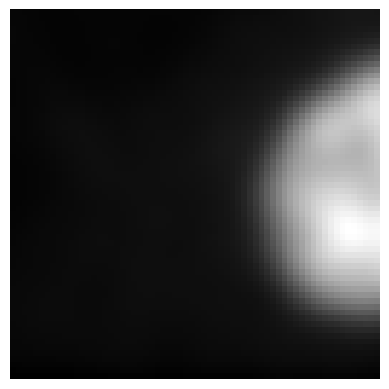

In [ ]:
file_path = output_folder + '/patches_dataset.h5/' + pd.read_csv('./_test_tfms/my_patches_datasets.csv')['image'][1]
im , meta, affine = hdf5_loader()(file_path)
show_image(im)


In [ ]:
meta

{'affine': array([[1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 0., 1.]]),
 'channels': '1',
 'depth': '1',
 'filepath': 'data_examples/Confocal_BPAE_B/HV110_P0500510006.png',
 'format': 'PNG',
 'frames': 'None',
 'height': '512',
 'kind': 'image',
 'layout': 'CZYX',
 'mode': 'L',
 'original_channel_dim': '0',
 'patch_size': '(64, 64)',
 'patch_transforms': 'None',
 'sequence': 'None',
 'shape': '(512, 512)',
 'size_after_tfms': 'torch.Size([1, 1, 512, 512])',
 'size_original': 'torch.Size([1, 1, 512, 512])',
 'size_output': '(1, 1, 512, 512)',
 'space': 'RAS',
 'spatial_shape': '(1, 512, 512)',
 'transforms': "{'GaussianSmoothd': {'time': 0.030797481536865234, 'params': {'keys': ('image',), 'allow_missing_keys': False, 'converter': {'__class__': 'GaussianSmooth', 'sigma': 3, 'approx': 'erf'}}}}",
 'width': '512',
 'patch_location': '(0, 64)'}

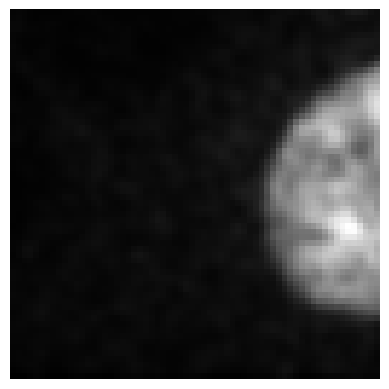

In [ ]:
file_path = output_folder + '/patches_dataset.h5/' + pd.read_csv('./_test_tfms/my_patches_datasets.csv')['gt'][1]
im , meta, affine = hdf5_loader()(file_path)
show_image(im)


In [ ]:
meta

{'affine': array([[1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 0., 1.]]),
 'channels': '1',
 'depth': '1',
 'filepath': 'data_examples/Confocal_BPAE_B/HV110_P0500510006.png',
 'format': 'PNG',
 'frames': 'None',
 'height': '512',
 'kind': 'image',
 'layout': 'CZYX',
 'mode': 'L',
 'original_channel_dim': '0',
 'patch_size': '(64, 64)',
 'patch_transforms': 'None',
 'sequence': 'None',
 'shape': '(512, 512)',
 'size_after_tfms': 'torch.Size([1, 1, 512, 512])',
 'size_original': 'torch.Size([1, 1, 512, 512])',
 'size_output': '(1, 1, 512, 512)',
 'space': 'RAS',
 'spatial_shape': '(1, 512, 512)',
 'transforms': "{'GaussianSmoothd': {'time': 0.0024483203887939453, 'params': {'keys': ('gt',), 'allow_missing_keys': False, 'converter': {'__class__': 'GaussianSmooth', 'sigma': 1, 'approx': 'erf'}}}}",
 'width': '512',
 'patch_location': '(0, 64)'}

In [ ]:
affine

array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]])

In [ ]:
data_paths = './data_examples'
# For the sake of simplicity, in this example we use the same folder for ground truth
colmap = {"image": "Confocal_BPAE_B","gt": "Confocal_BPAE_B"} 
output_folder = './_test_tfms'
patch_size = (64,64)
ProcessImageDataset(
    data_paths, 
    output_folder,
    'patches_dataset_random',
    patch_size, 
    num_patches=3,
    colmap=colmap, 
    patch_transforms=transforms_list, 
    image_splitter=RandomPatchSplitter, 
    random_seed=42, 
    )

Splitting dataset...

Processing split: train


100%|██████████| 5/5 [00:00<00:00, 30.89it/s]



Processing split: valid


100%|██████████| 2/2 [00:00<00:00, 32.49it/s]


Dataset processing complete. HDF5 file saved to: ./_test_tfms/patches_dataset_random.h5
Patch information saved to CSV: ./_test_tfms/patches_dataset_random.csv


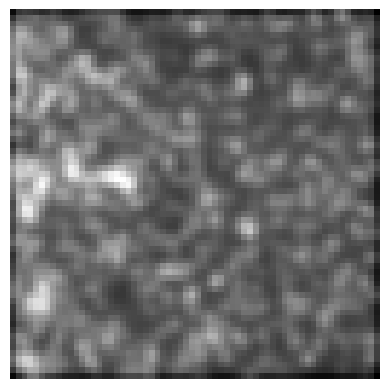

In [ ]:
file_path = output_folder + '/patches_dataset_random.h5/' + pd.read_csv('./_test_tfms/patches_dataset_random.csv')['gt'][1]
im , meta, affine = hdf5_loader()(file_path)
show_image(im)


In [ ]:
meta

{'affine': array([[1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 0., 1.]]),
 'channels': '1',
 'depth': '1',
 'filepath': 'data_examples/Confocal_BPAE_B/HV110_P0500510000.png',
 'format': 'PNG',
 'frames': 'None',
 'height': '512',
 'kind': 'image',
 'layout': 'CZYX',
 'mode': 'L',
 'original_channel_dim': '0',
 'patch_size': '(64, 64)',
 'patch_transforms': "{'GaussianSmoothd': {'__class__': 'GaussianSmoothd', 'keys': ('gt',), 'allow_missing_keys': False, 'converter': {'__class__': 'GaussianSmooth', 'sigma': 1, 'approx': 'erf'}}}",
 'sequence': 'None',
 'shape': '(512, 512)',
 'size_after_tfms': 'None',
 'size_original': 'torch.Size([1, 1, 512, 512])',
 'size_output': '(1, 1, 512, 512)',
 'space': 'RAS',
 'spatial_shape': '(1, 512, 512)',
 'transforms': '{}',
 'width': '512',
 'patch_location': '(24, 172)'}

### Substacks

In [ ]:
#| export
def dict2string(d, # The dictionary to convert.
                item_sep="_", # The separator between dictionary items (default is ", ").
                key_value_sep="", # The separator between keys and values (default is ": ").
                pad_zeroes=None, # The minimum width for integer values, padded with zeros. If None, no padding is applied.
                ):
    """
    Transforms a dictionary into a string with customizable separators and optional zero padding for integers.

    Returns the formatted dictionary as a string.
    """
    def format_value(value):
        if isinstance(value, int) and pad_zeroes is not None:
            return f"{value:0{pad_zeroes}d}"
        return str(value)
    
    return item_sep.join(f"{k}{key_value_sep}{format_value(v)}" for k, v in d.items())


In [ ]:
my_dict = {'C': 2, 'Z': 30, 'S': 1}
result = dict2string(my_dict, pad_zeroes=3)
print(result)

C002_Z030_S001


In [ ]:
#| export
def remove_singleton_dims(substack, # The extracted substack data.
                          order, # The dimension order string (e.g., 'CZYX').
                          ):
    """
    Remove dimensions with a size of 1 from both the substack and the order string.

    Returns: \n
        substack (np.array): The substack with singleton dimensions removed.
        new_order (str): The updated dimension order string.
    """
    new_order = ""
    new_shape = []
    
    for i, dim in enumerate(order):
        if substack.shape[i] > 1:  # Keep only dimensions with more than 1 slice
            new_order += dim
            new_shape.append(substack.shape[i])
    
    substack = substack.reshape(new_shape)  # Remove singleton dimensions
    return substack, new_order

In [ ]:
#| export
def extract_substacks(input_file, # Path to the input OME-TIFF file.
                      output_dir=None, # Directory to save the extracted substacks. If a list, the substacks will be saved in the corresponding subdirectories from the list.
                      indices=None,# A dictionary specifying which indices to extract. Keys can include 'C' for channel, 'Z' for z-slice, 'T' for time point, and 'S' for scene. If None, all indices are extracted.
                      split_dimension=None,# Dimension to split substacks along. If provided, separate substacks will be generated for each index in the split_dimension. Must be one of the keys in indices.
                      squeeze_dims=True, # Dimension to squeeze substacks along. 
                      *kwargs):
    """
    Extract substacks from a multidimensional OME-TIFF stack.

    """
    # Load the OME-TIFF file
    image = AICSImage(input_file)

    # Extract the base name of the input file (without path and extension)
    base_filename = os.path.splitext(os.path.basename(input_file))[0]   
    # Remove complex extensions like .ome.tiff or .ome.tif
    base_filename = os.path.splitext(base_filename)[0]
    
    # Get dimensions order
    order = image.dims.order

    # Update defaults with user-specified indices
    if indices is None:
        indices = dict()
        
    # Convert any numpy.int types in indices to Python int
    indices = {k: int(v) if isinstance(v, (np.integer, np.int64)) else v for k, v in indices.items()}

    # If split_dimension is provided, create substacks for each index in that dimension
    if split_dimension is not None and split_dimension in indices:
        # Extract the dimension indices from the input data
        split_indices = indices[split_dimension]
        if isinstance(split_indices, int):
            split_indices = [split_indices]  # Ensure it's a list even if a single index is passed

        # Ensure output_dir is a list of directories or convert to list of subfolder names by index
        if output_dir is not None and isinstance(output_dir, list):
            if len(output_dir) != len(split_indices):
                if len(output_dir) == 1:
                    output_dir_list = [os.path.join(output_dir[0], f"{split_dimension}_{i}") for i in split_indices]
                else:
                    raise ValueError(f"The number of subdirectories in output_dir ({len(output_dir)}) does not match the number of substacks ({len(split_indices)}).")
            else:
                output_dir_list = output_dir
        elif output_dir is not None:
            output_dir_list = [output_dir] * len(split_indices)
        else:
            output_dir_list = [None] * len(split_indices)  # No output_dir provided, substack is returned.

        # Loop through indices in the split dimension
        for i, idx in enumerate(split_indices):
            # Adjust the indices dictionary for the current index in split_dimension
            current_indices = indices.copy()
            current_indices[split_dimension] = int(idx) 
            
            # Extract the substack for the current index
            substack = image.get_image_data(order, **current_indices)
            
            # Remove singleton dimensions
            if squeeze_dims:
                substack, new_order = remove_singleton_dims(substack, order)
            else:
                new_order = order

            # Save the substack
            if output_dir is None:
                return substack  # Return the first substack if no output_dir is specified
            
            # Ensure the specific subfolder exists
            os.makedirs(output_dir_list[i], exist_ok=True)
            
            # Construct output filename
            output_filename = f"{base_filename}_substack_{dict2string(current_indices, *kwargs)}.ome.tiff"
            output_path = os.path.join(output_dir_list[i], output_filename)

            # Save the substack
            OmeTiffWriter.save(substack, output_path, dim_order=new_order)

            print(f"Extracted substack saved to: {output_path}")
    
    else:
        # No split_dimension provided, extract the entire substack
        substack = image.get_image_data(order, **indices)
        
        # Remove singleton dimensions
        if squeeze_dims:
            substack, new_order = remove_singleton_dims(substack, order)
        else:
            new_order = order

        if output_dir is None:
            return substack  # Return substack if no output_dir is provided

        # Ensure output directory exists
        os.makedirs(output_dir, exist_ok=True)
        
        # Construct output filename
        output_filename = f"{base_filename}_substack_{dict2string(indices, *kwargs)}.ome.tiff"
        output_path = os.path.join(output_dir, output_filename)

        # Save the substack
        OmeTiffWriter.save(substack, output_path, dim_order=new_order)

        print(f"Extracted substack saved to: {output_path}")


In [ ]:
output_dir = "./_test_folder/"
subdirs = [output_dir + folder for folder in ["channel_0", "channel_1", "channel_2"]]
subdirs

['./_test_folder/channel_0',
 './_test_folder/channel_1',
 './_test_folder/channel_2']

In [ ]:
[os.path.join([output_dir][0], f"{subdirs[0]}_{ii}") for ii in range(2)]

['./_test_folder/./_test_folder/channel_0_0',
 './_test_folder/./_test_folder/channel_0_1']

In [ ]:
filename = './data_examples/2155a4fe_3500000635_100X_20170227_E08_P21.ome.tiff'

# This extracts a single substack for channel 0, z-slice 5, and time point 0.
extract_substacks(filename, output_dir=output_dir, indices={"C": 0, "Z": range(35), "T": 0})


Attempted file (/home/bm/Documents/bioMONAI/nbs/data_examples/2155a4fe_3500000635_100X_20170227_E08_P21.ome.tiff) load with reader: <class 'bioio_ome_tiff.reader.Reader'> failed with error: bioio-ome-tiff does not support the image: '/home/bm/Documents/bioMONAI/nbs/data_examples/2155a4fe_3500000635_100X_20170227_E08_P21.ome.tiff'. Failed to parse XML for the provided file. Error: not well-formed (invalid token): line 1, column 6
Attempted file (/home/bm/Documents/bioMONAI/nbs/data_examples/2155a4fe_3500000635_100X_20170227_E08_P21.ome.tiff) load with reader: <class 'bioio_ome_tiff.reader.Reader'> failed with error: bioio-ome-tiff does not support the image: '/home/bm/Documents/bioMONAI/nbs/data_examples/2155a4fe_3500000635_100X_20170227_E08_P21.ome.tiff'. Failed to parse XML for the provided file. Error: not well-formed (invalid token): line 1, column 6
The image ends with .ome.tiff, which might indicate an OME-TIFF file format. You might want to install the `bioio-ome-tiff` plug-in fo

Extracted substack saved to: ./_test_folder/2155a4fe_3500000635_100X_20170227_E08_P21_substack_C0_Zrange(0, 35)_T0.ome.tiff


In [ ]:
# This extracts substacks for each channel (`C`) and saves them in separate subfolders named "C_0", "C_1", "C_2", etc.
extract_substacks(filename, output_dir=[output_dir], indices={"C": [0, 1, 2], "Z": 5, "T": 0}, split_dimension="C")


Attempted file (/home/bm/Documents/bioMONAI/nbs/data_examples/2155a4fe_3500000635_100X_20170227_E08_P21.ome.tiff) load with reader: <class 'bioio_ome_tiff.reader.Reader'> failed with error: bioio-ome-tiff does not support the image: '/home/bm/Documents/bioMONAI/nbs/data_examples/2155a4fe_3500000635_100X_20170227_E08_P21.ome.tiff'. Failed to parse XML for the provided file. Error: not well-formed (invalid token): line 1, column 6
Attempted file (/home/bm/Documents/bioMONAI/nbs/data_examples/2155a4fe_3500000635_100X_20170227_E08_P21.ome.tiff) load with reader: <class 'bioio_ome_tiff.reader.Reader'> failed with error: bioio-ome-tiff does not support the image: '/home/bm/Documents/bioMONAI/nbs/data_examples/2155a4fe_3500000635_100X_20170227_E08_P21.ome.tiff'. Failed to parse XML for the provided file. Error: not well-formed (invalid token): line 1, column 6
The image ends with .ome.tiff, which might indicate an OME-TIFF file format. You might want to install the `bioio-ome-tiff` plug-in fo

Extracted substack saved to: ./_test_folder/C_0/2155a4fe_3500000635_100X_20170227_E08_P21_substack_C0_Z5_T0.ome.tiff
Extracted substack saved to: ./_test_folder/C_1/2155a4fe_3500000635_100X_20170227_E08_P21_substack_C1_Z5_T0.ome.tiff
Extracted substack saved to: ./_test_folder/C_2/2155a4fe_3500000635_100X_20170227_E08_P21_substack_C2_Z5_T0.ome.tiff


In [ ]:

# This extracts substacks for each channel and saves them in directories "channel_0", "channel_1", and "channel_2".
extract_substacks(filename, output_dir=subdirs, indices={"C": [0, 1, 2], "Z": 5}, split_dimension="C")


Attempted file (/home/bm/Documents/bioMONAI/nbs/data_examples/2155a4fe_3500000635_100X_20170227_E08_P21.ome.tiff) load with reader: <class 'bioio_ome_tiff.reader.Reader'> failed with error: bioio-ome-tiff does not support the image: '/home/bm/Documents/bioMONAI/nbs/data_examples/2155a4fe_3500000635_100X_20170227_E08_P21.ome.tiff'. Failed to parse XML for the provided file. Error: not well-formed (invalid token): line 1, column 6
Attempted file (/home/bm/Documents/bioMONAI/nbs/data_examples/2155a4fe_3500000635_100X_20170227_E08_P21.ome.tiff) load with reader: <class 'bioio_ome_tiff.reader.Reader'> failed with error: bioio-ome-tiff does not support the image: '/home/bm/Documents/bioMONAI/nbs/data_examples/2155a4fe_3500000635_100X_20170227_E08_P21.ome.tiff'. Failed to parse XML for the provided file. Error: not well-formed (invalid token): line 1, column 6
The image ends with .ome.tiff, which might indicate an OME-TIFF file format. You might want to install the `bioio-ome-tiff` plug-in fo

Extracted substack saved to: ./_test_folder/channel_0/2155a4fe_3500000635_100X_20170227_E08_P21_substack_C0_Z5.ome.tiff
Extracted substack saved to: ./_test_folder/channel_1/2155a4fe_3500000635_100X_20170227_E08_P21_substack_C1_Z5.ome.tiff
Extracted substack saved to: ./_test_folder/channel_2/2155a4fe_3500000635_100X_20170227_E08_P21_substack_C2_Z5.ome.tiff


In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()